In [ ]:
!pip install wbgapi statsmodels -q

#Bloque A 
 
 -- Pregunta 22 -- 
 
Tabla Maestra:
 
             Grupo  R2 corr(CA,ŷ)  R3 corr(TB,ŷ)  R4 corr(I,ŷ)  R5 σ(I)/σ(C)  R6 corr(S,I)
País                                                                                      
USA   Desarrollado         -0.232         -0.212         0.530         0.796         0.687
DEU   Desarrollado         -0.022         -0.008         0.270         1.637        -0.265
CHN      Emergente          0.082          0.104         0.123         0.916         0.838
PER      Emergente         -0.249         -0.058         0.444         0.665         0.564
CHL      Emergente         -0.306         -0.271         0.501         0.707         0.124
KOR      Emergente         -0.627         -0.642         0.396         1.773         0.612
TUR      Emergente         -0.393         -0.461         0.399         0.966         0.810
 

-- R7: Correlación de la CA con el ciclo económico por grupos --
Grupo
Desarrollado   -0.1270
Emergente      -0.2986
Name: R2 

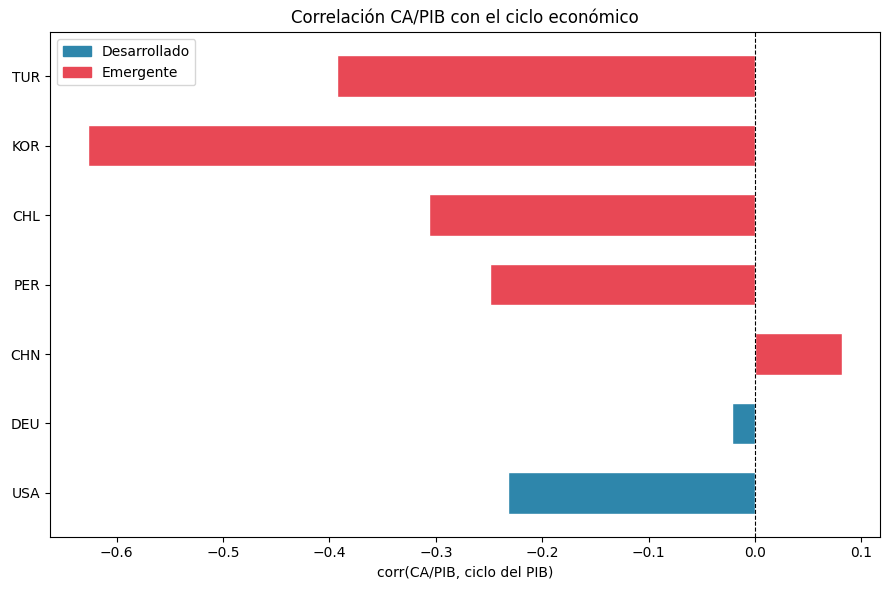

In [ ]:
# Librerias:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# Grupo de paises :
countries = {
    'USA': 'Desarrollado',
    'DEU': 'Desarrollado', #Alemania
    'CHN': 'Emergente',
    'PER': 'Emergente',
    'CHL': 'Emergente',
    'KOR': 'Emergente',
    'TUR': 'Emergente',
}

# Indicadores WDI :
indicators = {
    'NY.GDP.MKTP.KD':   'gdp_real',
    'BN.CAB.XOKA.GD.ZS':'ca_gdp',
    'NE.RSB.GNFS.ZS':   'tb_gdp',
    'NE.GDI.TOTL.ZS':   'inv_gdp',
    'NY.GNS.ICTR.ZS':   'sav_gdp',
    'NE.CON.TOTL.ZS':   'cons_gdp',
}

# Bloque A

#Pregunta 22

results = []  # Vector de R

for code, grupo in countries.items(): #Peru, emergente

    # Datos
    raw = wb.data.DataFrame(
        list(indicators.keys()),
        economy=code,
        time=range(1990, 2024)
    )
    df = raw.T
    df.columns = [indicators[c] for c in raw.index]
    df.index = [int(str(i).replace('YR', '')) for i in df.index]
    df = df.sort_index().astype(float)

    # Filtro HP : extraer el ciclo del PIB
    df_clean = df['gdp_real'].dropna()
    cycle, _ = hpfilter(x=np.log(df_clean), lamb=6.25)
    df['gdp_cycle'] = cycle.reindex(df.index)

    # Estadisticos ciclicos ( R2 a R6 )
    corr_CA  = df['gdp_cycle'].corr(df['ca_gdp'])   # R2: Correlación de la Cuenta Corriente y PBI (CICLO)
    corr_TB  = df['gdp_cycle'].corr(df['tb_gdp'])   # R3: Correlación de la Balanza Comercial y PBI
    corr_I   = df['gdp_cycle'].corr(df['inv_gdp'])  # R4
    vol_ratio= df['inv_gdp'].std() / df['cons_gdp'].std()  # R5
    corr_SI  = df['sav_gdp'].corr(df['inv_gdp'])    # R6

    results.append({
        'País':  code,
        'Grupo': grupo,
        'R2 corr(CA,ŷ)': round(corr_CA,  3),
        'R3 corr(TB,ŷ)': round(corr_TB,  3),
        'R4 corr(I,ŷ)':  round(corr_I,   3),
        'R5 σ(I)/σ(C)':  round(vol_ratio,3),
        'R6 corr(S,I)':  round(corr_SI,  3),
    })

# Tabla de todos los paises
tabla = pd.DataFrame(results).set_index('País')

print(" # Bloque A ")
print(" ")
print(" -- Pregunta 22 -- ")
print(" ")
print("Tabla Maestra:")
print(" ")
print(tabla.to_string())
print(" ")

# Cálculo del promedio por grupo
resumen_grupos = tabla.groupby('Grupo')['R2 corr(CA,ŷ)'].mean()

print("\n-- R7: Correlación de la CA con el ciclo económico por grupos --")
print(resumen_grupos)
print(" ")

# Gráfico de barras de corr(CA/PIB, ŷ)
fig, ax = plt.subplots(figsize=(9, 6))
colores = {'Desarrollado': '#2E86AB', 'Emergente': '#E84855'}

for i, (idx, row) in enumerate(tabla.iterrows()):
    ax.barh(y=idx, width=row['R2 corr(CA,ŷ)'],
            color=colores[row['Grupo']], edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('corr(CA/PIB, ciclo del PIB)')
ax.set_title('Correlación CA/PIB con el ciclo económico')

leyenda = [Patch(color='#2E86AB', label='Desarrollado'),
           Patch(color='#E84855', label='Emergente')]
ax.legend(handles=leyenda)

plt.tight_layout()
plt.show()

# -- Pregunta 23 --

**(a) ¿Para cuántos países se cumple R2 (CA contracíclica)? ¿Es la CA más contracíclica en emergentes que en desarrollados, como predice R7? ¿Qué dice este patrón sobre la relevancia relativa del canal de inversión frente al de suavización del consumo en cada grupo?**


R2 mide la correlación entre la cuenta corriente y el ciclo económico, prediciendo que dicha correlación es negativa, es decir, que ante un boom económico los países tienen incentivos para aumentar su inversión financiándose con ahorro externo, lo que deteriora la CA. De los 7 países analizados, 6 cumplen esta predicción: Estados Unidos (−0.232), Alemania (−0.022), Perú (−0.249), Chile (−0.306), Corea del Sur (−0.627) y Turquía (−0.393). El único que no cumple es China (+0.082), lo cual puede explicarse por la presencia de políticas que restringen los flujos de capital y por un alto nivel de ahorro interno.

Por otro lado, se puede afirmar que la R7 sí se cumple: los paises emergentes presentan una CA más contracíclica que los desarrollados. Este patrón puede entenderse a partir de los dos canales que determinan el comportamiento de la CA.

El primer canal es la suavización del consumo: ante un shock positivo transitorio, los hogares ahorran parte del ingreso adicional prestándolo al exterior, lo que mejora la CA y le da un componente procíclico. El segundo es el canal de inversión: en un boom, las empresas anticipan mayores retornos y aumentan su inversión financiándose con deuda externa, deteriorando la CA y haciéndola contracíclica. Estos dos canales operan simultáneamente pero en direcciones opuestas, y el signo observado de la correlación nos dice cuál domina en cada grupo. En los emergentes, donde existen más oportunidades de inversión no explotadas y los shocks son de mayor magnitud, domina el canal de inversión, produciendo correlaciones altamente negativas. En los desarrollados, en cambio, ambos canales tienden a compensarse en mayor medida, lo que explica correlaciones más cercanas a cero, como el caso de Alemania (−0.022) que los dos canales se compensan llegando casi a un punto acíclico.

En síntesis, el canal de inversión es el principal determinante del comportamiento contracíclico de la CA en economías emergentes, mientras que en las economías desarrolladas el canal de suavización del consumo recupera relevancia relativa, atenuando la contracíclicidad que el modelo con inversión predice.


---


**(b) ¿Se cumple R6 para todos los países? Si algún país muestra una correlación S–I particularmente baja, ¿qué podría indicar sobre el grado de integración financiera internacional de ese país?**

R6 predice una correlación positiva entre el ahorro doméstico y la inversión doméstica: un aumento en el ahorro local debería traducirse en mayor inversión local. Sin embargo, en una economía con perfecta movilidad de capital, como supone el modelo, esta relación no necesariamente tiene que cumplirse, ya que el ahorro fluiría hacia donde el retorno sea mayor, no necesariamente quedándose en el país de origen. Según los datos, R6 se cumple en 6 de los 7 países, con la excepción clara de Alemania (−0.265), que es el único caso donde más ahorro doméstico se asocia con una menor inversión doméstica. Por otro lado,Chile (+0.124), aunque técnicamente positivo, muestra una correlación débil.

Una correlación S–I particularmente baja indica que el ahorro doméstico y la inversión doméstica están desconectados; el país financia su inversión con ahorro externo o exporta su propio ahorro, lo cual es exactamente lo que se esperaría bajo una perfecta movilidad de capitales.

Estos resultados conectan directamente con el puzzle de Feldstein y Horioka (1980), quienes documentaron en un corte transversal de países que los que más ahorran también más invierten domésticamente, resultado bajo perfecta movilidad de capital. La explicación que le podemos dar es por la época, en 1980 los mercados de capitales estaban poco integrados, con controles estrictos, pocos instrumentos financieros y altos costos de transacción, por lo que el capital tendía a quedarse localmente. Hoy, la integración financiera es alta gracias a la globalización, haciendo que el puzzle se resuelva; el ahorro efectivamente fluya buscando el mayor retorno.

En síntesis, la magnitud de la correlación S–I funciona como un indicador inverso del grado de integración financiera internacional; cuanto más baja, más abierto y conectado está el país con los mercados de capital globales. El modelo que desarrollamos en las partes I–IV asume como condición la movilidad perfecta de capitales, pero que en la práctica varía entre países.



---
**(c) ¿En qué países falla R5 (σ(I)/σ(C) > 1)? ¿Qué tipo de economías exhiben σ(C) > σ(I) y qué sugiere esto sobre la naturaleza de los shocks que enfrentan?**

R5 predice que la inversión debería ser más volátil que el consumo, porque los hogares suavizan su consumo intertemporal mientras que la inversión reacciona directamente las las oportunidades productivas sin ese amortiguamiento. Sin embargo, R5 falla en 5 de los 7 países: Estados Unidos (0.796), China (0.916), Perú (0.665), Chile (0.707) y Turquía (0.966). Solo Alemania (1.637) y Corea del Sur (1.773) cumplen la regularidad, siendo precisamente los dos países con estructuras industriales más orientadas a la inversión intensiva en capital.

Este incumplimiento a la regla no es aleatorio; con la excepción de Estados Unidos, todos los países que fallan R5 son emergentes, lo que nos indica que la naturaleza de sus shocks es distinta a la que el modelo simple asume. Aguiar y Gopinath (2007) explican que en economías emergentes los shocks no son principalmente transitorios sino de tendencia, desplazando permanentemente las expectativas de ingreso de largo plazo. Lo cual nos dice que ante un shock transitorio, el hogar piensa "este año gané más de lo normal pero el año que viene volverá a la normalidad", por lo que suaviza y el consumo se mueve poco. Ante un shock de tendencia, el hogar revisa toda su trayectoria de consumo futuro de golpe, generando fluctuaciones de consumo mucho mayores. La inversión, en cambio, responde más gradualmente en ambos casos porque los proyectos de capital requieren tiempo de instalación y planificación. El resultado es que en emergentes σ(C) > σ(I), exactamente lo opuesto a lo que predice el modelo.

Por otro lado, Estados Unidos que es economía desarrollada, presenta un su σ(I)/σ(C) = 0.796 indicando que su consumo es relativamente volátil. Sin embargo, esto no se debe a shocks de tendencia,  sino al gran desarrollo de su mercado de crédito al consumo. Los hogares americanos tienen mayor acceso a deuda para sostener el consumo incluso ante shocks, lo que paradójicamente amplifica su volatilidad en lugar de reducirla.



---
***Análisis por países:***

- **China:**

China presenta una cuenta corriente (+0.082) y una balanza comercial (+0.104) procíclicas, es decir, cuando la economía mejora, ambas variables también mejoran, lo opuesto a lo predicho por el modelo.

El modelo asume perfecta movilidad de capital y ausencia de intervención estatal estos dos supuestos no los cumple China. Los primeros factores que explican este acontecimiento son los controles de capital y la política cambiaria administrada. Rana (2023) explica que las autoridades chinas han optado por mantener una "trinidad imposible": control del tipo de cambio, política monetaria independiente y movilidad de capitales restringida. El resultado es  que por un lado, el ahorro chino no puede salir libremente al exterior, quedándose dentro del país para financiar inversión doméstica o acumularse como reservas; y por otro, el tipo de cambio administrado mantiene artificialmente elevadas las exportaciones netas incluso en épocas de boom. Esto implica que durante las épocas de bonanza, el aumento de exportaciones combinado con la limitada salida de capitales genere mayores superávits externos, volviendo la CA procíclica en lugar de contracíclica.

El segundo factor vendría a ser el rol del dólar como moneda de reserva mundial. China ha acumulado históricamente enormes reservas internacionales denominadas en dólares, en parte como seguro tras la crisis asiática de 1997–98, y también como subproducto de su política cambiaria. Esta acumulación de reservas implica que, durante los booms exportadores, el superávit de CA significa un aumento del consumo o inversión domestica, sino que se dirige hacia un ahorro en dólares, reforzando aún más la prociclicidad de la CA.

En conjunto, la prociclicidad observada en China es por la fuerte estructura institucional, que el modelo de las partes I–IV no contempla, haciéndolo incapaz de replicar el comportamiento chino.

- **Alemania:**

Alemania cuenta con dos fallas de acuerdo con lo predicho por el modelo. Por un lado, una correlación S–I de −0.265, el único valor negativo de toda la muestra, lo que indica que un mayor ahorro doméstico se asocia con menor inversión doméstica, lo opuesto al resultado que deberia arrojar el R6. Por otro lado, una CA prácticamente acíclica (−0.022), lo que significa que el ciclo económico doméstico casi no tiene poder explicativo sobre el comportamiento de la cuenta corriente, contradiciendo la predicción de R2.

Una de las primeras explicaciones es la pertenencia a una unión monetaria sin política cambiaria propia. El modelo teórico supone que ante un desequilibrio externo existe un mecanismo de ajuste. Normalmente, la apreciación del tipo de cambio frena las exportaciones y corrige el superávit; sin embargo, Alemania no dispone de ese mecanismo, dado que comparte el euro. Esto produce que la CA alemana responda más a la dinámica exportadora global que al ciclo económico doméstico, lo que explica directamente por qué R2 es prácticamente nulo y la correlación se aproxima a la aciclicidad.

El segundo factor es el ahorro corporativo estructural. Las grandes empresas manufactureras alemanas generan enormes ganancias que no distribuyen como consumo ni reinvierten domésticamente, sino que exportan lo ahorrado como capital hacia el resto del mundo. Este mecanismo explica la correlación S–I negativa; ya que cuando Alemania ahorra más a nivel corporativo, ese ahorro no financia inversión local sino que sale al exterior, exactamente lo opuesto a lo que predice R6. Además, al operar dentro de la eurozona, esta exportación de capital no enfrenta riesgo cambiario, lo que termina reforzando el mecanismo.

En conjunto, tanto la aciclicidad de la CA como la correlación S–I negativa responden a que Alemania opera bajo la unión monetaria y modelo corporativo que exporta su ahorro; lo cual el modelo de las partes I–IV no contempla, haciéndolo incapaz de replicar su comportamiento.


 # Bloque B 
 
 -- Pregunta 24 -- 
 
Economía de dotaciones  → R1: corr(CA/PIB, ŷ) = +0.318
Economía con inversión  → R2: corr(CA/PIB, ŷ) = -0.033
 


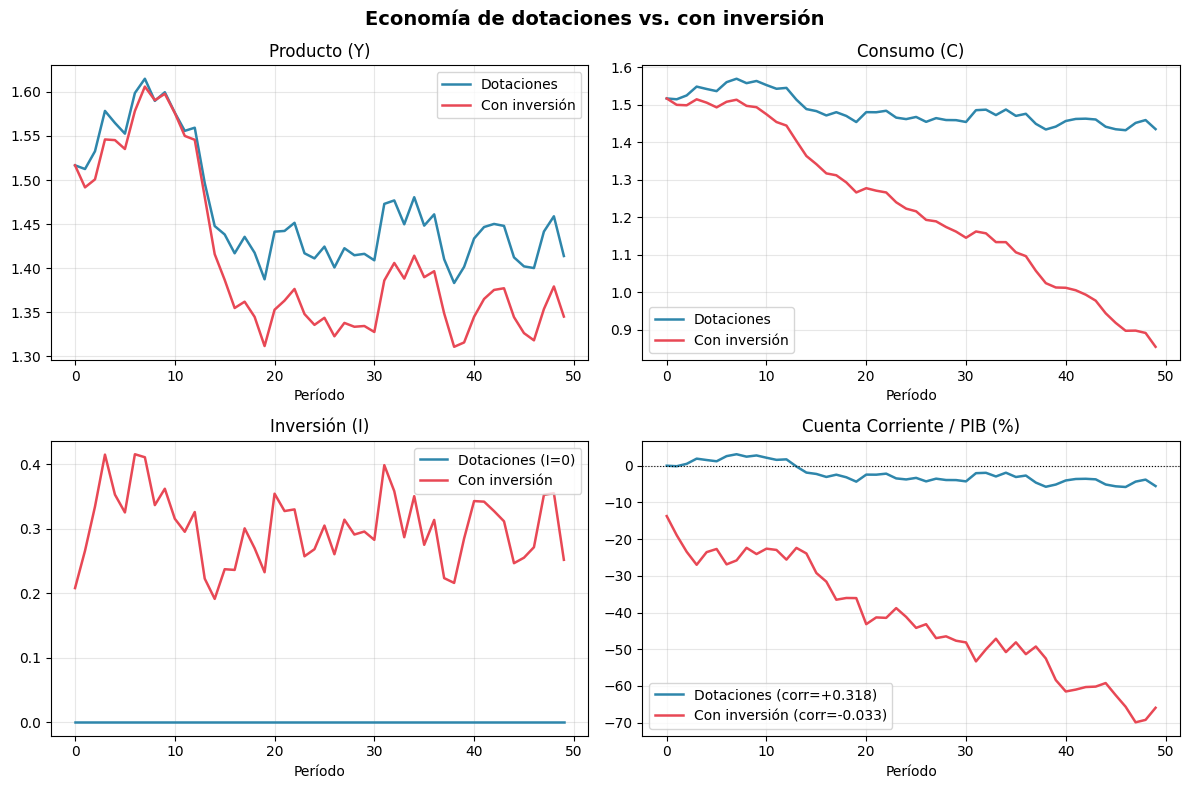

In [ ]:
# Bloque B

# Pregunta 24

# ── Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# ── Función simular_economia
def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                     rho=0.90, sigma_eps=0.02, T=50, seed=42,
                     con_inversion=True):
    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)
    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]
    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))
    y_ss = k_ss ** alpha
    c_ss = y_ss - delta * k_ss

    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T);   b = np.zeros(T+1)
    k[0] = k_ss; b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])
        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1/(1-alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1-delta) * k[t]
            i[t] = k[t+1] - (1-delta) * k[t]
        else:
            k[t+1] = k[t]; i[t] = 0
        c[t] = (1/(1+beta)) * (y[t] + r_star*b[t] + beta*y_ss)
        b[t+1] = (1+r_star)*b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]
    TB = y - c - i
    S  = y + r_star*b[:-1] - c
    return pd.DataFrame({
        'Y':y, 'C':c, 'I':i, 'S':S, 'CA':CA, 'TB':TB,
        'CA_Y':CA/y*100, 'TB_Y':TB/y*100,
        'I_Y':i/y*100,   'S_Y':S/y*100
    })

# ── Simulaciones
df_dotacion = simular_economia(con_inversion=False, seed=42)  # dotaciones
df_inversion = simular_economia(con_inversion=True,  seed=42)  # con inversión

# ── Ciclo del PIB para cada escenario
cycle_dot, _ = hpfilter(np.log(df_dotacion['Y']), lamb=6.25)
cycle_inv, _ = hpfilter(np.log(df_inversion['Y']), lamb=6.25)

# ── Correlaciones CA/PIB con el ciclo
corr_dot = cycle_dot.corr(df_dotacion['CA_Y'])
corr_inv = cycle_inv.corr(df_inversion['CA_Y'])

print(" # Bloque B ")
print(" ")
print(" -- Pregunta 24 -- ")
print(" ")
print(f"Economía de dotaciones  → R1: corr(CA/PIB, ŷ) = {corr_dot:+.3f}")
print(f"Economía con inversión  → R2: corr(CA/PIB, ŷ) = {corr_inv:+.3f}")
print(" ")

# ── Panel 2×2
periodos = np.arange(len(df_dotacion))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Economía de dotaciones vs. con inversión',
             fontsize=14, fontweight='bold')

# Colores
c_dot = '#2E86AB'   # azul — dotaciones
c_inv = '#E84855'   # rojo — con inversión

# Panel 1 — Producto
axes[0,0].plot(periodos, df_dotacion['Y'], color=c_dot,
               label='Dotaciones', linewidth=1.8)
axes[0,0].plot(periodos, df_inversion['Y'], color=c_inv,
               label='Con inversión', linewidth=1.8)
axes[0,0].set_title('Producto (Y)')
axes[0,0].legend()

# Panel 2 — Consumo
axes[0,1].plot(periodos, df_dotacion['C'], color=c_dot, linewidth=1.8, label='Dotaciones')
axes[0,1].plot(periodos, df_inversion['C'], color=c_inv, linewidth=1.8, label='Con inversión')
axes[0,1].set_title('Consumo (C)')
axes[0,1].legend()

# Panel 3 — Inversión
axes[1,0].plot(periodos, df_dotacion['I'], color=c_dot,
               linewidth=1.8, label='Dotaciones (I=0)')
axes[1,0].plot(periodos, df_inversion['I'], color=c_inv, linewidth=1.8,
               label='Con inversión')
axes[1,0].set_title('Inversión (I)')
axes[1,0].legend()

# Panel 4 — CA/PIB
axes[1,1].plot(periodos, df_dotacion['CA_Y'], color=c_dot, linewidth=1.8,
               label=f'Dotaciones (corr={corr_dot:+.3f})')
axes[1,1].plot(periodos, df_inversion['CA_Y'], color=c_inv, linewidth=1.8,
               label=f'Con inversión (corr={corr_inv:+.3f})')
axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1,1].set_title('Cuenta Corriente / PIB (%)')
axes[1,1].legend()

for ax in axes.flatten():
    ax.set_xlabel('Período')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -- Pregunta 24 --

**¿En cuál economía la cuenta corriente es procíclica y en cuál contracíclica? Explique su respuesta conectando con R1 y R2: ¿qué canal está apagado en la economía de dotaciones que se enciende cuando hay inversión?**

Cuando la economía es de dotaciones, la CA tiene una conducta procíclica (+0.318), cumpliendo con lo predicho por R1. Mientras que la economía con inversión presenta una CA contracíclica (−0.033), cumpliendo R2 de forma débil.

En la economía de dotaciones, el único canal activo es la suavización del consumo. Cuando ocurre un shock positivo de productividad, el ingreso sube transitoriamente. Los hogares reconocen que ese aumento no es permanente, por lo que ahorran parte del exceso prestándolo al exterior mediante la CA. Como ingreso y CA suben juntos, la correlación es positiva. El canal de inversión está completamente apagado porque en esta economía no hay capital que acumular, aquí el ingreso llega como una dotación exógena sobre la cual los hogares no tienen ninguna decisión de inversión.

En la economía con inversión, ese canal se enciende. Ahora, ante el mismo shock positivo de productividad, las empresas observan que su capital es más productivo y deciden invertir en aumentarlo. Para financiar esa inversión adicional, se endeudan con el exterior, lo que deteriora la CA precisamente cuando la economía va bien. Este efecto domina sobre el motivo de suavización del consumo, revirtiendo el signo de la correlación de positivo a negativo y volviendo la CA contracíclica.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# ── Función simular_economia
def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                     rho=0.90, sigma_eps=0.02, T=50, seed=42,
                     con_inversion=True):
    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)
    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]
    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))
    y_ss = k_ss ** alpha
    c_ss = y_ss - delta * k_ss

    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T);   b = np.zeros(T+1)
    k[0] = k_ss; b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])
        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1/(1-alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1-delta) * k[t]
            i[t] = k[t+1] - (1-delta) * k[t]
        else:
            k[t+1] = k[t]; i[t] = 0
        c[t] = (1/(1+beta)) * (y[t] + r_star*b[t] + beta*y_ss)
        b[t+1] = (1+r_star)*b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]
    TB = y - c - i
    S  = y + r_star*b[:-1] - c
    return pd.DataFrame({
        'Y':y, 'C':c, 'I':i, 'S':S, 'CA':CA, 'TB':TB,
        'CA_Y':CA/y*100, 'TB_Y':TB/y*100,
        'I_Y':i/y*100,   'S_Y':S/y*100
    })

# ── Valores base
BASE = dict(alpha=0.33, beta=0.96, delta=0.10,
            r_star=0.04, rho=0.90, sigma_eps=0.02, T=50, seed=42)

# ── Variaciones:
variaciones = {
    'rho':    {'valores': [0.30, 0.70, 0.95], 'label': r'$\rho$'},
    'alpha':  {'valores': [0.15, 0.33, 0.50], 'label': r'$\alpha$'},
    'r_star': {'valores': [0.02, 0.04, 0.08], 'label': r'$r^*$'},
}

colores = ['#2E86AB', '#F4A261', '#E84855']  # azul, naranja, rojo

# ── Calculo de desviaciones estantar
def get_stats(df):
    y_clean = np.log(np.abs(df['Y']) + 1e-10)
    cycle, _ = hpfilter(y_clean, lamb=6.25)
    vol_I  = df['I'].std()
    vol_CA = df['CA_Y'].std()
    corr   = cycle.corr(df['CA_Y'])
    return vol_I, vol_CA, corr

# ── Tabla resumen
print("=" * 75)
print(f"{'Parám.':<12} {'Valor':<8} {'Economía':<20} "
      f"{'σ(I)':<10} {'σ(CA)':<10} {'corr(CA,ŷ)':<10}")
print("=" * 75)

for param, info in variaciones.items():
    for con_inv in [True, False]:
        tipo = 'Con inversión' if con_inv else 'Dotaciones'
        for val in info['valores']:
            params = BASE.copy()
            params[param] = val
            params['con_inversion'] = con_inv
            df = simular_economia(**params)
            vol_I, vol_CA, corr = get_stats(df)
            print(f"{info['label']:<12} {val:<8} {tipo:<20} "
                  f"{vol_I:<10.4f} {vol_CA:<10.4f} {corr:+.4f}")
    print("-" * 75)

Parám.       Valor    Economía             σ(I)       σ(CA)      corr(CA,ŷ)
$\rho$       0.3      Con inversión        0.0546     12.1346    -0.1098
$\rho$       0.7      Con inversión        0.0534     12.9605    -0.0622
$\rho$       0.95     Con inversión        0.0573     17.7499    -0.0243
$\rho$       0.3      Dotaciones           0.0000     0.9860     +0.8080
$\rho$       0.7      Dotaciones           0.0000     1.4131     +0.5728
$\rho$       0.95     Dotaciones           0.0000     3.6728     +0.2247
---------------------------------------------------------------------------
$\alpha$     0.15     Con inversión        0.0135     7.9224     +0.0332
$\alpha$     0.33     Con inversión        0.0550     15.4310    -0.0334
$\alpha$     0.5      Con inversión        0.2538     23.8987    -0.0353
$\alpha$     0.15     Dotaciones           0.0000     2.5850     +0.3177
$\alpha$     0.33     Dotaciones           0.0000     2.5850     +0.3177
$\alpha$     0.5      Dotaciones           0.

In [3]:
import pandas as pd

dot = pd.DataFrame({
    'Parám.':       ['ρ', 'α', 'r*'],
    'ΔI':           ['0', '0', '0'],
    'ΔCA':          ['↑', '0', '↑'],
    'Intuición':    [
        'Shocks más persistentes generan desvíos prolongados del ingreso; la CA se vuelve más volátil pero menos procíclica porque el hogar anticipa que el ingreso elevado durará, suavizando menos agresivamente',
        'Al no haber capital, α no entra en la producción, por lo que el parámetro es irrelevante en este caso',
        'Mayor r* amplifica los flujos de intereses sobre deuda, elevando la volatilidad de la CA; la procliclidad se reduce levemente porque la deuda introduce una fuente adicional de variación no ligada al ciclo económico'
    ]
})

inv = pd.DataFrame({
    'Parám.':       ['ρ', 'α', 'r*'],
    'ΔI':           ['Incierto', '↑', 'Incierto'],
    'ΔCA':          ['↑', '↑', '↑'],
    'Intuición':    [
        'Mayor persistencia eleva la volatilidad de la CA fuertemente, pero reduce la contraciclicidad. Los shocks más duraderos hacen que inversión y ahorro se muevan juntos, diluyendo el rol amortiguador de la CA',
        'Mayor α amplifica tanto la inversión como la CA; la correlación se mantiene levemente negativa y estable, confirmando que el canal de inversión domina y la CA permanece contracíclica independientemente de α',
        'Mayor r* encarece el capital y comprime la inversión, pero a r*=8% la correlación cambia de signo (de -0.13 a +0.04), indicando que la CA se vuelve procíclica. El ahorro termina dominando al canal de inversión'
    ]
})
print(" -- Pregunta 25 -- ")
print(" ")
print("DOTACIONES")
display(dot.style.set_properties(**{'text-align': 'center'})
              .hide(axis='index'))

print("\nCON INVERSIÓN")
display(inv.style.set_properties(**{'text-align': 'center'})
              .hide(axis='index'))

 -- Pregunta 25 -- 
 
DOTACIONES


Parám.,ΔI,ΔCA,Intuición
ρ,0,↑,"Shocks más persistentes generan desvíos prolongados del ingreso; la CA se vuelve más volátil pero menos procíclica porque el hogar anticipa que el ingreso elevado durará, suavizando menos agresivamente"
α,0,0,"Al no haber capital, α no entra en la producción, por lo que el parámetro es irrelevante en este caso"
r*,0,↑,"Mayor r* amplifica los flujos de intereses sobre deuda, elevando la volatilidad de la CA; la procliclidad se reduce levemente porque la deuda introduce una fuente adicional de variación no ligada al ciclo económico"



CON INVERSIÓN


Parám.,ΔI,ΔCA,Intuición
ρ,Incierto,↑,"Mayor persistencia eleva la volatilidad de la CA fuertemente, pero reduce la contraciclicidad. Los shocks más duraderos hacen que inversión y ahorro se muevan juntos, diluyendo el rol amortiguador de la CA"
α,↑,↑,"Mayor α amplifica tanto la inversión como la CA; la correlación se mantiene levemente negativa y estable, confirmando que el canal de inversión domina y la CA permanece contracíclica independientemente de α"
r*,Incierto,↑,"Mayor r* encarece el capital y comprime la inversión, pero a r*=8% la correlación cambia de signo (de -0.13 a +0.04), indicando que la CA se vuelve procíclica. El ahorro termina dominando al canal de inversión"


In [ ]:
#---------------- SIMULACIÓN PARA LA CALIBRACIÓN AL "OJO" ----------------------

import numpy as np
import pandas as pd
from itertools import product
from statsmodels.tsa.filters.hp_filter import hpfilter


def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                     rho=0.90, sigma_eps=0.02, T=50, seed=42,
                     con_inversion=True):
    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)
    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]
    A = np.exp(ln_A)
    k_ss = (alpha / (1/beta - 1 + delta))**(1/(1 - alpha))
    y_ss = k_ss**alpha
    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T);   b = np.zeros(T+1)
    k[0] = k_ss; b[0] = 0
    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])
        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta))**(1/(1 - alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1 - delta) * k[t]
            i[t] = k[t+1] - (1 - delta) * k[t]
        else:
            k[t+1] = k[t]; i[t] = 0
        c[t] = (1/(1+beta)) * (y[t] + r_star * b[t] + beta * y_ss)
        b[t+1] = (1+r_star) * b[t] + y[t] - c[t] - i[t]
    CA = b[1:] - b[:-1]; TB = y - c - i; S = y + r_star * b[:-1] - c
    return pd.DataFrame({'Y': y, 'C': c, 'I': i, 'S': S, 'CA': CA, 'TB': TB,
                         'CA_Y': CA/y*100, 'TB_Y': TB/y*100,
                         'I_Y': i/y*100,   'S_Y': S/y*100,
                         'C_Y': c/y*100})


def calcular_estadisticos(params, seed=42, T=50):
    try:
        # Simular para la semilla 42
        df = simular_economia(**params, T=T, seed=seed)

        if df['C'].min() < 0 or df['Y'].min() <= 0:
            return None

        # Filtro HP
        cycle, _ = hpfilter(np.log(df['Y']), lamb=6.25)
        cyc = pd.Series(cycle.values)

        return {
            'corr_CA': cyc.corr(df['CA_Y']),
            'corr_TB': cyc.corr(df['TB_Y']),
            'corr_I':  cyc.corr(df['I_Y']),
            'vol_rat': df['I_Y'].std() / df['C_Y'].std(),
            'corr_SI': df['S_Y'].corr(df['I_Y'])
        }
    except Exception:
        return None


# Datos de turquia
targets = {
    'corr_CA': -0.393,
    'corr_TB': -0.461,
    'corr_I':  +0.399,
    'vol_rat':  0.966,
    'corr_SI': +0.810,
}
TOL = 0.15  # tolerancia para encontrar un momento "acertado"

#Escenarios posibles
grid = {
    'r_star':    [0.02, 0.03, 0.04, 0.05, 0.06],
    'alpha':     [0.30, 0.33, 0.36, 0.40, 0.45, 0.50],
    'delta':     [0.05, 0.06, 0.08, 0.10, 0.12],
    'rho':       [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95],
    'sigma_eps': [0.02, 0.03, 0.04, 0.05, 0.07, 0.10],
}

keys   = list(grid.keys())
values = list(grid.values())
combos = list(product(*values))
print(f"Total de combinaciones a evaluar: {len(combos):,}")

# Busqueda del escenario
rows = []
for i, combo in enumerate(combos):
    p = dict(zip(keys, combo))
    p['beta'] = 1 / (1 + p['r_star'])   # condición β(1+r*)=1
    p['con_inversion'] = True

    #Calcular los estadisticos
    m = calcular_estadisticos(p)
    if m is None:
        continue

    # Score: suma de errores cuadráticos sobre los 5 momentos
    score = sum((m[k] - targets[k])**2 for k in targets)

    # Cuántos momentos están dentro de ±TOL
    n_hit = sum(abs(m[k] - targets[k]) < TOL for k in targets)

    rows.append({
        'alpha':     p['alpha'],
        'beta':      round(p['beta'], 4),
        'delta':     p['delta'],
        'r_star':    p['r_star'],
        'rho':       p['rho'],
        'sigma_eps': p['sigma_eps'],
        #Estadisticos ciclicos
        'sim_corr_CA': round(m['corr_CA'], 3),
        'sim_corr_TB': round(m['corr_TB'], 3),
        'sim_corr_I':  round(m['corr_I'],  3),
        'sim_vol_rat': round(m['vol_rat'],  3),
        'sim_corr_SI': round(m['corr_SI'],  3),
        # métricas de ajuste
        'score':  round(score, 4),
        'n_hit':  n_hit,
    })

    if (i+1) % 500 == 0:
        print(f"  Progreso: {i+1}/{len(combos)} combinaciones evaluadas...")

# ── Tabla de todos los resultados
df_grid = pd.DataFrame(rows)
df_grid = df_grid.sort_values(['n_hit', 'score'], ascending=[False, True]).reset_index(drop=True)

print(f"\nCombinaciones válidas encontradas: {len(df_grid):,}")
print(f"\nDistribución de momentos acertados (n_hit):")
print(df_grid['n_hit'].value_counts().sort_index(ascending=False).to_string())

# Guardar tabla completa
df_grid.to_csv('grid_search_turquia_semilla42.csv', index=False)
print("\nTabla completa guardada en: grid_search_turquia_semilla42.csv")

# Buscamos las 10 mejores combinaciones
print("\n" + "="*75)
print("TOP 10 — Combinaciones con más momentos acertados (menor score si empate)")
print("="*75)
top10 = df_grid.head(10)
cols_mostrar = ['alpha','beta','delta','r_star','rho','sigma_eps',
                'sim_corr_CA','sim_corr_TB','sim_corr_I','sim_vol_rat','sim_corr_SI',
                'n_hit','score']
print(top10[cols_mostrar].to_string(index=True))

# Combinación ganadora
best = df_grid.iloc[0]
print("\n" + "="*75)
print("★  MEJOR COMBINACIÓN ENCONTRADA")
print("="*75)
print(f"\nParámetros:")
print(f"  alpha     = {best['alpha']}")
print(f"  beta      = {best['beta']}  [= 1/(1+r*), condición β(1+r*)=1]")
print(f"  delta     = {best['delta']}")
print(f"  r_star    = {best['r_star']}")
print(f"  rho       = {best['rho']}")
print(f"  sigma_eps = {best['sigma_eps']}")

print(f"\n{'Momento':<12} {'Simulado':>10} {'Empírico':>10} {'Error':>8} {'OK (±{TOL})':>12}")
print("  " + "-"*55)
pares = [('corr_CA', best['sim_corr_CA'], -0.393),
         ('corr_TB', best['sim_corr_TB'], -0.461),
         ('corr_I',  best['sim_corr_I'],  +0.399),
         ('vol_rat', best['sim_vol_rat'],   0.966),
         ('corr_SI', best['sim_corr_SI'],  +0.810)]

for nombre, sim, emp in pares:
    err = abs(sim - emp)
    ok  = f"✓" if err < TOL else "✗"
    print(f"  {nombre:<12} {sim:>+10.3f} {emp:>+10.3f} {err:>8.3f} {ok:>10}")

print(f"\n  Momentos acertados: {int(best['n_hit'])}/5")
print(f"  Score (MSE total):  {best['score']:.4f}")

Total de combinaciones a evaluar: 6,300
  Progreso: 500/6300 combinaciones evaluadas...
  Progreso: 1000/6300 combinaciones evaluadas...
  Progreso: 1500/6300 combinaciones evaluadas...
  Progreso: 2000/6300 combinaciones evaluadas...
  Progreso: 2500/6300 combinaciones evaluadas...
  Progreso: 3000/6300 combinaciones evaluadas...
  Progreso: 3500/6300 combinaciones evaluadas...
  Progreso: 4000/6300 combinaciones evaluadas...
  Progreso: 4500/6300 combinaciones evaluadas...
  Progreso: 5000/6300 combinaciones evaluadas...
  Progreso: 5500/6300 combinaciones evaluadas...

Combinaciones válidas encontradas: 6,115

Distribución de momentos acertados (n_hit):
n_hit
4       3
3     547
2    1969
1    2251
0    1345

Tabla completa guardada en: grid_search_turquia_semilla42.csv

TOP 10 — Combinaciones con más momentos acertados (menor score si empate)
   alpha    beta  delta  r_star  rho  sigma_eps  sim_corr_CA  sim_corr_TB  sim_corr_I  sim_vol_rat  sim_corr_SI  n_hit   score
0   0.50  0.95

In [ ]:
# Pregunta 26

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import textwrap

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                     rho=0.90, sigma_eps=0.02, T=50, seed=42,
                     con_inversion=True):
    """
    Simula una economia pequena y abierta por T periodos.
    con_inversion = True : economia con produccion y capital.
    con_inversion = False: economia de dotaciones puras.
    """
    np.random.seed(seed)
    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)
    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]
    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta))**(1/(1 - alpha))
    y_ss = k_ss**alpha
    c_ss = y_ss - delta * k_ss

    k = np.zeros(T+1); y = np.zeros(T); c = np.zeros(T)
    i = np.zeros(T);   b = np.zeros(T+1)
    k[0] = k_ss; b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])
        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta))**(1/(1 - alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1 - delta) * k[t]
            i[t] = k[t+1] - (1 - delta) * k[t]
        else:
            k[t+1] = k[t]; i[t] = 0
        c[t] = (1/(1+beta)) * (y[t] + r_star * b[t] + beta * y_ss)
        b[t+1] = (1+r_star) * b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]; TB = y - c - i; S = y + r_star * b[:-1] - c
    return pd.DataFrame({'Y': y, 'C': c, 'I': i, 'S': S, 'CA': CA, 'TB': TB,
                         'CA_Y': CA/y*100, 'TB_Y': TB/y*100,
                         'I_Y': i/y*100,   'S_Y': S/y*100,
                         'C_Y': c/y*100})


def calcular_estadisticos(df):
    cycle, _ = hpfilter(np.log(df['Y'] + 1e-8), lamb=6.25)
    corr_CA   = cycle.corr(df['CA_Y'])
    corr_TB   = cycle.corr(df['TB_Y'])
    corr_I    = cycle.corr(df['I_Y'])
    vol_ratio = df['I_Y'].std() / df['C_Y'].std()
    corr_SI   = df['S_Y'].corr(df['I_Y'])
    return {
        'corr(CA,ŷ)': round(corr_CA, 3),
        'corr(TB,ŷ)': round(corr_TB, 3),
        'corr(I,ŷ)':  round(corr_I,  3),
        'σ(I)/σ(C)':  round(vol_ratio, 3),
        'corr(S,I)':  round(corr_SI,  3),
    }


# Datos de Turquía
empiricos_TUR = {
    'corr(CA,ŷ)': -0.393,
    'corr(TB,ŷ)': -0.461,
    'corr(I,ŷ)':  +0.399,
    'σ(I)/σ(C)':   0.966,
    'corr(S,I)':  +0.810,
}
print("Estadisticos Ciclicos de Turquía (1990–2023, ítem 22):")
for k, v in empiricos_TUR.items():
    print(f"  {k:15s} = {v:+.3f}")


#PASO 1: AL OJO ----------------------------------------------------------------

#Calibración al "ojo"
params_ojo = dict(
    alpha     = 0.5,
    beta      = 0.9524,
    delta     = 0.05,
    r_star    = 0.05,
    rho       = 0.6,
    sigma_eps = 0.04,
    con_inversion = True,
    T   = 50,
    seed = 42,
)

#Simulación
df_ojo       = simular_economia(**params_ojo)
estadisticos_ojo = calcular_estadisticos(df_ojo)

print("\n" + "="*65)
print("PASO 1 — Calibración al ojo")
print("="*65)
print(" ")
print("Parámetros ajustados:")
base = {'alpha':0.33,'beta':0.96,'delta':0.10,'r_star':0.04,'rho':0.90,'sigma_eps':0.02}
for p, v in {k: params_ojo[k] for k in ['alpha','beta','delta','r_star','rho','sigma_eps']}.items():
    dir_ = "↑" if v > base[p] else ("↓" if v < base[p] else "=")
    print(f"  {p:12s} = {v}  ({dir_} desde {base[p]})")

#Tabla de comparación
print(f"\n  {'Estadisticos Ciclicos':<20} {'Al ojo':>10} {'Empírico':>12} {'¿Cerca?':>12}")
print("  " + "-"*56)
for k in empiricos_TUR:
    v_ojo = estadisticos_ojo[k]
    v_emp = empiricos_TUR[k]
    err   = abs(v_ojo - v_emp)

    cerca = "✓" if err < 0.15 else "Δ"
    print(f"  {k:<20} {v_ojo:>+10.3f} {v_emp:>+12.3f} {cerca:>12}")

n_ok = sum(abs(estadisticos_ojo[k] - empiricos_TUR[k]) < 0.15 for k in empiricos_TUR)
print(f"\n  Momentos acertados: {n_ok}/5")

print("")
texto = 'Los valores no son del todo al "ojo", dado que busqué un escenario donde se minimice la diferencia entre el escenario de la pregunta 22 y el que calcula Simular_economia(). Sin embargo, no se pudo encontrar un escenario perfecto que le atine a todo; se falló en la correlación del ahorro con la inversión. Esto se debe a que el modelo teórico asume libre movilidad de capitales y, por eso, la correlación tiende a cero; no obstante, esto no se está cumpliendo en la realidad, dada la alta correlación.'
print(textwrap.fill(texto, width=80))



#PASO 2: CALIBRACIÓN CON LITERATURA --------------------------------------------

#Parametros del paper - Trimestral

beta_trim  = 0.98
alpha_FG  = 0.36
delta_trim = 0.025
r_trim    = 0.01
rho_trim   = 0.95
sig_trim  = 0.0172

#Conversion a anual

beta_a  = beta_trim**4
delta_a = 1 - (1 - delta_trim)**4
r_a     = (1 + r_trim)**4 - 1
rho_a   = rho_trim**4
sig_a   = sig_trim * np.sqrt(4)

print("\n" + "="*65)
print("PASO 2 — Calibración Fernández & Gulan (2015)")
print("="*65)
print(" ")
print("Conversión trimestral → anual:")
print(f"  alpha:     {alpha_FG}          ")
print(f"  beta:      {beta_trim}^4            = {beta_a:.4f}")
print(f"  delta:     1-(1-{delta_trim})^4   = {delta_a:.4f}")
print(f"  r_star:    (1+{r_trim})^4 - 1    = {r_a:.4f}")
print(f"  rho:       {rho_trim}^4            = {rho_a:.4f}")
print(f"  sigma_eps: {sig_trim} × √4       = {sig_a:.4f}")

#Usar los datos en simular_economia
params_FG = dict(
    alpha     = alpha_FG,
    beta      = beta_a,
    delta     = delta_a,
    r_star    = r_a,
    rho       = rho_a,
    sigma_eps = sig_a,
    con_inversion = True,
    T   = 50,
    seed = 42,
)

df_FG       = simular_economia(**params_FG)
estadisticos_FG = calcular_estadisticos(df_FG)

print(f"\n  {'Momento':<15} {'F&G 2015':>12} {'Empírico':>12}")
print("  " + "-"*41)
for k in empiricos_TUR:
    v_FG  = estadisticos_FG[k]
    v_emp = empiricos_TUR[k]
    print(f"  {k:<15} {v_FG:>+12.3f} {v_emp:>+12.3f}")


#PASO 3: TABLA COMPARATIVA Y DISCUSIÓN -----------------------------------------

print("\n" + "="*65)
print("PASO 3 — TABLA COMPARATIVA Y DISCUSIÓN")
print("="*65)

print(" ")
print("TABLA COMPARATIVA DE LOS PARÁMETROS DE TURQUIA: ")
print(" ")
df_params = pd.DataFrame({
    'Parámetro':       ['α', 'β', 'δ', 'r*', 'ρ', 'σ_ε'],
    'Significado':     ['Part. capital', 'Factor desc.', 'Depreciación',
                        'Tasa int. mundial', 'Persist. TFP', 'Volat. shock TFP'],
    'Al ojo (TUR)':    [0.45, 0.9615, 0.06, 0.04, 0.80, 0.03],
    'F&G 2015 (anual)':[round(alpha_FG,4), round(beta_a,4), round(delta_a,4),
                        round(r_a,4), round(rho_a,4), round(sig_a,4)],
})
print(df_params.to_string(index=False))

print(" ")
print("TABLA COMPARATIVA DE LOS ESTADISTICOS CICLICOS DE TURQUIA: ")

print(" ")
df_estadisticos = pd.DataFrame({
    'Momento':          list(empiricos_TUR.keys()),
    'Empírico (TUR)':   list(empiricos_TUR.values()),
    'Al ojo':           [estadisticos_ojo[k] for k in empiricos_TUR],
    'F&G 2015 (sim.)':  [estadisticos_FG[k]  for k in empiricos_TUR],
    '¿Se parece?':        ['✓' if abs(estadisticos_ojo[k]-empiricos_TUR[k]) < 0.15
                         else '✗' for k in empiricos_TUR],
})
print(df_estadisticos.to_string(index=False))



Estadisticos Ciclicos de Turquía (1990–2023, ítem 22):
  corr(CA,ŷ)      = -0.393
  corr(TB,ŷ)      = -0.461
  corr(I,ŷ)       = +0.399
  σ(I)/σ(C)       = +0.966
  corr(S,I)       = +0.810

PASO 1 — Calibración al ojo
 
Parámetros ajustados:
  alpha        = 0.5  (↑ desde 0.33)
  beta         = 0.9524  (↓ desde 0.96)
  delta        = 0.05  (↓ desde 0.1)
  r_star       = 0.05  (↑ desde 0.04)
  rho          = 0.6  (↓ desde 0.9)
  sigma_eps    = 0.04  (↑ desde 0.02)

  Estadisticos Ciclicos     Al ojo     Empírico      ¿Cerca?
  --------------------------------------------------------
  corr(CA,ŷ)               -0.268       -0.393            ✓
  corr(TB,ŷ)               -0.357       -0.461            ✓
  corr(I,ŷ)                +0.526       +0.399            ✓
  σ(I)/σ(C)                +1.113       +0.966            ✓
  corr(S,I)                +0.036       +0.810            Δ

  Momentos acertados: 4/5

Los valores no son del todo al "ojo", dado que busqué un escenario donde se
minimi

# -- Pregunta 26 --
 **¿Qué fricciones harían falta modelar con la función simular_economia() para cerrar la brecha entre lo que calculó al ojo y lo que el paper dice?**

La primera brecha que saca a relucir la tabla es la de corr(S,I). Ni la estimación al ojo ni la calibración de Fernández & Gulan logran replicar la alta correlación S–I que presenta Turquía. Lo que faltaría es relajar el supuesto de perfecta movilidad de capitales, incorporando una prima de riesgo endógena al modelo. En simular_economia(), r* es fijo y exógeno, por lo que el país puede endeudarse libremente a cualquier escala; cuando hay un boom, la inversión sube pero el ahorro doméstico no necesita subir porque el financiamiento externo es barato e ilimitado. En cambio, si el spread soberano aumenta cuando la deuda externa crece como en Fernández & Gulan, el endeudamiento externo se encarece justo cuando más se necesita, forzando al país a financiar su inversión con ahorro doméstico. Esto refleja que, en la práctica, el costo del financiamiento externo no es independiente del nivel de endeudamiento del país, y esa dependencia es la que genera la correlación S–I positiva que los datos muestran.

La segunda brecha que deja ver la tabla es la de corr(CA, ŷ) y corr(TB, ŷ). Fernández & Gulan muestran −0.094 y −0.153, respectivamente, mientras que Turquía presenta −0.393 y −0.461. Se puede observar que la contracicilidad observada casi cuadruplica a la simulada. Lo que faltaría es incorporar un acelerador financiero que amplifique el ciclo crediticio. En simular_economia(), r* es fijo y exógeno, por lo que el costo del financiamiento externo no reacciona ante la posición patrimonial de las empresas; cuando hay un boom, la inversión sube, pero el spread no cae para realimentarla. En cambio, si las empresas se endeudan en moneda extranjera, como ocurre en Turquía, un shock positivo de productividad mejora su balance sheet, comprime el spread y habilita aún más inversión; por otro lado, si hay una caída del producto se deterioran las hojas de balance y contrae el crédito de golpe. Este mecanismo hace que la cuenta corriente responda de forma mucho más pronunciada al ciclo de lo que un modelo con tasa de interés exógena puede generar.

En conclusión, en simular_economia(), r* es una constante que desconecta el ahorro del ciclo y aplana la respuesta de la cuenta corriente; en la realidad turca, el spread soberano sube y baja con el ciclo, encadenando el ahorro doméstico a la inversión y amplificando los movimientos de la cuenta corriente. Incorporar una prima de riesgo endógena, como hace Fernández & Gulan mediante el vínculo entre deuda externa y spread, permitiría que el modelo replique simultáneamente la correlación S–I y la contracicilidad de la cuenta corriente que caracterizan a Turquía.